In [20]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils.utils import printmessage
import glob
import tqdm
import gc

In [21]:
def get_motif_count(path):
    block_df = pd.read_pickle(path+"/block_df.pkl")
    block_df["11mer"] = block_df["motif"].apply(lambda x: x[5:-5])
    motif_count = block_df["11mer"].value_counts()
    motif_count.to_pickle(path+"/11mer_count.pkl")
    del block_df
    gc.collect()
    return motif_count

In [22]:
motif_count_ON0092 = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0092/ON0092/result/dorado-070/intermediates/11mer_count.pkl")
motif_count_ON0096 = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0096/result/dorado-070/intermediates/11mer_count.pkl")
motif_count_ON0099 = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0099/result/dorado-070/intermediates/11mer_count.pkl")

In [26]:
motif_count_ON0118 = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0118/ON0118/result/intermediates/11mer_count.pkl")

In [27]:
ca_list = [motif_count_ON0092, motif_count_ON0096]
m6a_list = [motif_count_ON0099, motif_count_ON0118]

In [28]:
ca_df = pd.concat(ca_list, axis=1).fillna(0).sum(axis=1)
print(ca_df)
m6a_df = pd.concat(m6a_list, axis=1).fillna(0).sum(axis=1)
print(m6a_df)

11mer
AAAAAAAAAAA    30453
CCACCACCACC     6955
CAAAAAAAAAA     3298
UAAAAAAAAAA     2671
GUGAAACUGAA     2164
               ...  
UUUCGAGGGGA       66
GUGAGAGUGUG       78
GGGGGAGGAGA       55
UGAGGAGGAGU       59
GGUGGAGGAGG       47
Length: 1048576, dtype: int64
11mer
AAAAAAAAAAA    19423.0
CCACCACCACC     5636.0
CAAAAAAAAAA     2684.0
UAAAAAAAAAA     1968.0
CACACACACAC     1731.0
                ...   
AAGAGAGGGUC       40.0
UGUGAAGGGGG       28.0
CGAAGAGGGGA       26.0
GAGAGAGUGAU       26.0
CGGAGAGAAGA       23.0
Length: 1048576, dtype: float64


In [29]:
ca_df = pd.DataFrame(ca_df)
m6a_df = pd.DataFrame(m6a_df)
ca_df.columns = ["count"]
m6a_df.columns = ["count"]
ca_df["11mer"] = ca_df.index
m6a_df["11mer"] = m6a_df.index
ca_df["9mer"] = ca_df["11mer"].apply(lambda x: x[1:-1])
m6a_df["9mer"] = m6a_df["11mer"].apply(lambda x: x[1:-1])
print(ca_df)
print(m6a_df)

             count        11mer       9mer
11mer                                     
AAAAAAAAAAA  30453  AAAAAAAAAAA  AAAAAAAAA
CCACCACCACC   6955  CCACCACCACC  CACCACCAC
CAAAAAAAAAA   3298  CAAAAAAAAAA  AAAAAAAAA
UAAAAAAAAAA   2671  UAAAAAAAAAA  AAAAAAAAA
GUGAAACUGAA   2164  GUGAAACUGAA  UGAAACUGA
...            ...          ...        ...
UUUCGAGGGGA     66  UUUCGAGGGGA  UUCGAGGGG
GUGAGAGUGUG     78  GUGAGAGUGUG  UGAGAGUGU
GGGGGAGGAGA     55  GGGGGAGGAGA  GGGGAGGAG
UGAGGAGGAGU     59  UGAGGAGGAGU  GAGGAGGAG
GGUGGAGGAGG     47  GGUGGAGGAGG  GUGGAGGAG

[1048576 rows x 3 columns]
               count        11mer       9mer
11mer                                       
AAAAAAAAAAA  19423.0  AAAAAAAAAAA  AAAAAAAAA
CCACCACCACC   5636.0  CCACCACCACC  CACCACCAC
CAAAAAAAAAA   2684.0  CAAAAAAAAAA  AAAAAAAAA
UAAAAAAAAAA   1968.0  UAAAAAAAAAA  AAAAAAAAA
CACACACACAC   1731.0  CACACACACAC  ACACACACA
...              ...          ...        ...
AAGAGAGGGUC     40.0  AAGAGAGGGUC  AGAGAGGGU
UGUGAAGG

In [30]:
ca_df_count_9mer = ca_df.groupby("9mer")[["count"]].sum()
m6a_df_count_9mer = m6a_df.groupby("9mer")[["count"]].sum()

print(ca_df_count_9mer)
print(m6a_df_count_9mer)

           count
9mer            
AAAAAAAAA  43674
AAAAAAAAC   4166
AAAAAAAAG   5793
AAAAAAAAU   5767
AAAAAAACA   5342
...          ...
UUUUAUUGU   4919
UUUUAUUUA   5413
UUUUAUUUC   4551
UUUUAUUUG   5530
UUUUAUUUU   5810

[65536 rows x 1 columns]
             count
9mer              
AAAAAAAAA  27365.0
AAAAAAAAC   1220.0
AAAAAAAAG   1300.0
AAAAAAAAU   2334.0
AAAAAAACA   1091.0
...            ...
UUUUAUUGU   3916.0
UUUUAUUUA   3369.0
UUUUAUUUC   2615.0
UUUUAUUUG   3430.0
UUUUAUUUU   3612.0

[65536 rows x 1 columns]


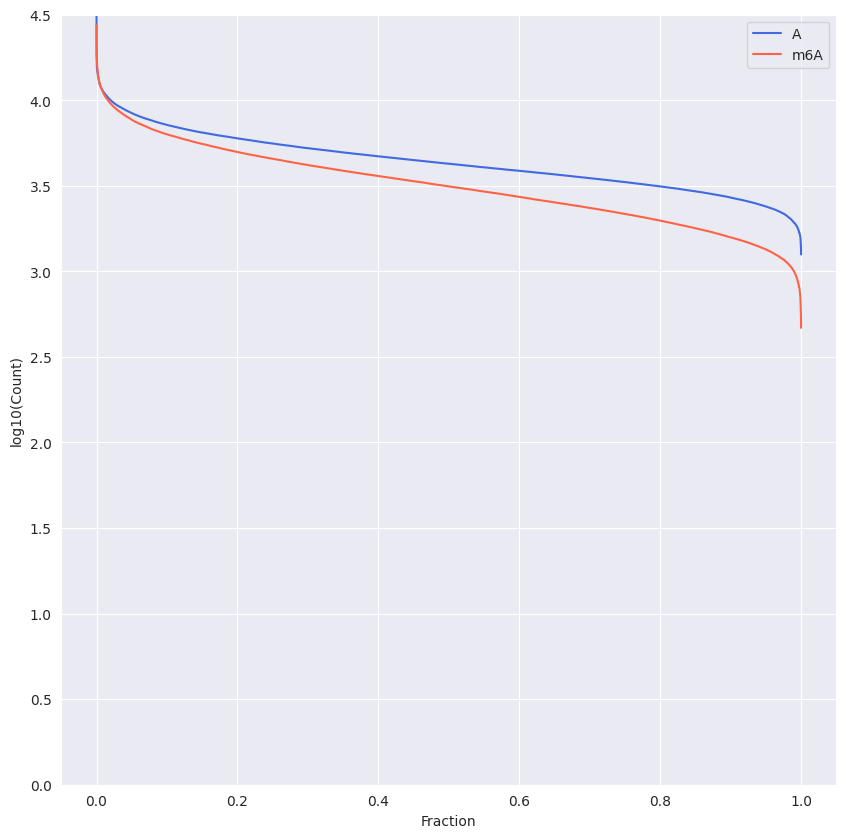

In [31]:
## Plot inverse CDF
fig, ax = plt.subplots(figsize=(10, 10))


ax.plot(np.linspace(0, 1, len(ca_df_count_9mer), endpoint=False),  np.log10(np.sort(ca_df_count_9mer["count"].values)[::-1]), label="A", color="royalblue")
ax.plot(np.linspace(0, 1, len(m6a_df_count_9mer), endpoint=False), np.log10(np.sort(m6a_df_count_9mer["count"].values)[::-1]), label="m6A", color="tomato")
ax.set_xlabel("Fraction")
ax.set_ylabel("log10(Count)")
ax.set_ylim(0, 4.5)
ax.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/motif_cdf_9mer.pdf")
plt.show()



In [32]:
ca_df = ca_df.reset_index(drop=True)
m6a_df = m6a_df.reset_index(drop=True)

In [33]:
ca_df_count_11mer = ca_df.groupby("11mer")[["count"]].sum()
m6a_df_count_11mer = m6a_df.groupby("11mer")[["count"]].sum()

print(ca_df_count_11mer)
print(m6a_df_count_11mer)

             count
11mer             
AAAAAAAAAAA  30453
AAAAAAAAAAC    702
AAAAAAAAAAG    698
AAAAAAAAAAU   1434
AAAAAAAAACA    384
...            ...
UUUUUAUUUGU    333
UUUUUAUUUUA    348
UUUUUAUUUUC    327
UUUUUAUUUUG    367
UUUUUAUUUUU    397

[1048576 rows x 1 columns]
               count
11mer               
AAAAAAAAAAA  19423.0
AAAAAAAAAAC    328.0
AAAAAAAAAAG    302.0
AAAAAAAAAAU    961.0
AAAAAAAAACA    145.0
...              ...
UUUUUAUUUGU    210.0
UUUUUAUUUUA    216.0
UUUUUAUUUUC    214.0
UUUUUAUUUUG    265.0
UUUUUAUUUUU    290.0

[1048576 rows x 1 columns]


In [34]:
print(ca_df_count_11mer.mean())
print(m6a_df_count_11mer.mean())

count    292.703725
dtype: float64
count    227.835191
dtype: float64


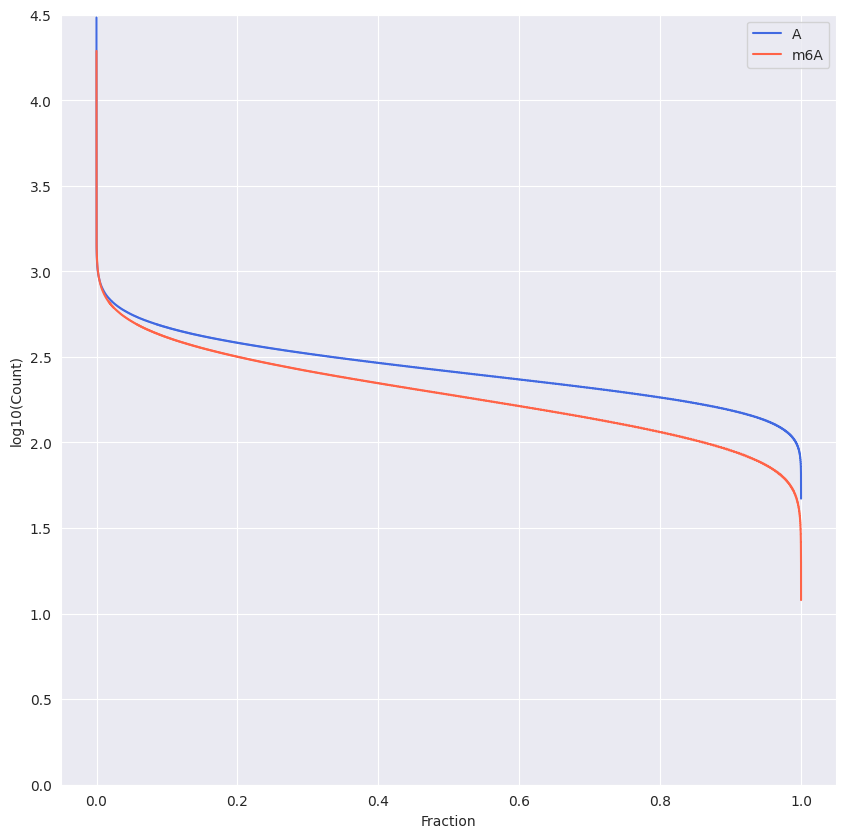

In [35]:
## Plot inverse CDF
fig, ax = plt.subplots(figsize=(10, 10))


ax.plot(np.linspace(0, 1, len(ca_df_count_11mer), endpoint=False),  np.log10(np.sort(ca_df_count_11mer["count"].values)[::-1]), label="A", color="royalblue")
ax.plot(np.linspace(0, 1, len(m6a_df_count_11mer), endpoint=False), np.log10(np.sort(m6a_df_count_11mer["count"].values)[::-1]), label="m6A", color="tomato")
ax.set_xlabel("Fraction")
ax.set_ylabel("log10(Count)")
ax.set_ylim(0, 4.5)
ax.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/motif_cdf_11mer.pdf")
plt.show()



In [36]:
ca_df_count_11mer.to_csv("/extdata3/baeklab/Jungmin/RNAmod/coverage/airna_11mer_ca.tsv", sep="\t")
m6a_df_count_11mer.to_csv("/extdata3/baeklab/Jungmin/RNAmod/coverage/airna_11mer_m6a.tsv", sep="\t")